# Agent behavior

One greedy episode with trained agents, recorded step by step. Shows temperature
control against the fruit's ideal band, the route taken vs the target route, and
per-step rewards. Train first: `python -m training.train --agents temperature routing`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import networkx as nx
import pandas as pd


def _find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "training" / "config.py").exists():
            return candidate
    raise RuntimeError("project root not found (training/config.py)")


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core.config import FruitKey
from core.fruits import get_params
from env.training_env import ColdChainTrainingEnv
from training.config import COMPARE_SEED, env_config, load_agents

AGENTS = ["temperature", "routing"]
SEED = COMPARE_SEED
KIND_ORDER = ["farm", "hub", "dc", "retail"]
KIND_COLOR = {"farm": "tab:green", "hub": "tab:blue", "dc": "tab:orange", "retail": "tab:red"}

plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## Record one episode

In [2]:
def record_episode(env, agents, learners):
    obs, _ = env.reset()
    s0 = env._state
    meta = {
        "fruit": s0.shipment.fruit_type.value,
        "source": s0.shipment.current_node,
        "target": s0.shipment.target_node,
        "weather": s0.ambient_weather.value,
        "ambient_temp_c": s0.ambient_temp_c,
    }
    path = [s0.shipment.current_node]
    rows = []
    done = False
    while not done:
        actions = {a: agents[a].act(obs[a], explore=False) for a in agents}
        obs, rewards, terminated, truncated, _ = env.step(actions)
        s = env._state.shipment
        row = {
            "tick": env._state.tick,
            "desired": s.desired_temperature_c,
            "sensor": s.sensor_temperature_c,
            "spoilage_risk": s.spoilage_risk,
            "energy": env._state.energy_usage,
            "route_travel_time": env._state.route_travel_time,
            "route_emissions": env._state.route_emissions,
        }
        for a in learners:
            row[f"reward_{a}"] = rewards[a]
        rows.append(row)
        path.append(s.current_node)
        done = terminated["__all__"] or truncated["__all__"]
    return pd.DataFrame(rows), path, meta


env = ColdChainTrainingEnv(env_config(SEED, AGENTS))
agents = load_agents(env, AGENTS)
df, path, meta = record_episode(env, agents, AGENTS)
graph = env._state.graph
fruit = get_params(FruitKey(meta["fruit"]))
delivered = path[-1] == meta["target"]

print(f"{meta['fruit']}: {meta['source']} -> {meta['target']} "
      f"({meta['weather']}, ambient {meta['ambient_temp_c']:.1f} C), "
      f"{len(df)} steps, delivered={delivered}")
df.head()

banana: farm_1 -> retail_1 (sunny, ambient 27.9 C), 3 steps, delivered=True


,tick,desired,sensor,spoilage_risk,energy,route_travel_time,route_emissions,reward_temperature,reward_routing
0,1,15.080696,15.235364,0.031214,1.266496,1.0,12.534612,-4.527570,-2.565600
1,2,11.263573,13.882716,0.058684,1.401761,2.0,17.783774,-2.333090,-2.111759
2,3,12.468891,13.876684,0.086139,1.402364,5.0,39.026023,-2.345365,94.014384


## Temperature control

Setpoint (action) vs sensor vs the fruit's ideal band; spoilage risk and energy below.

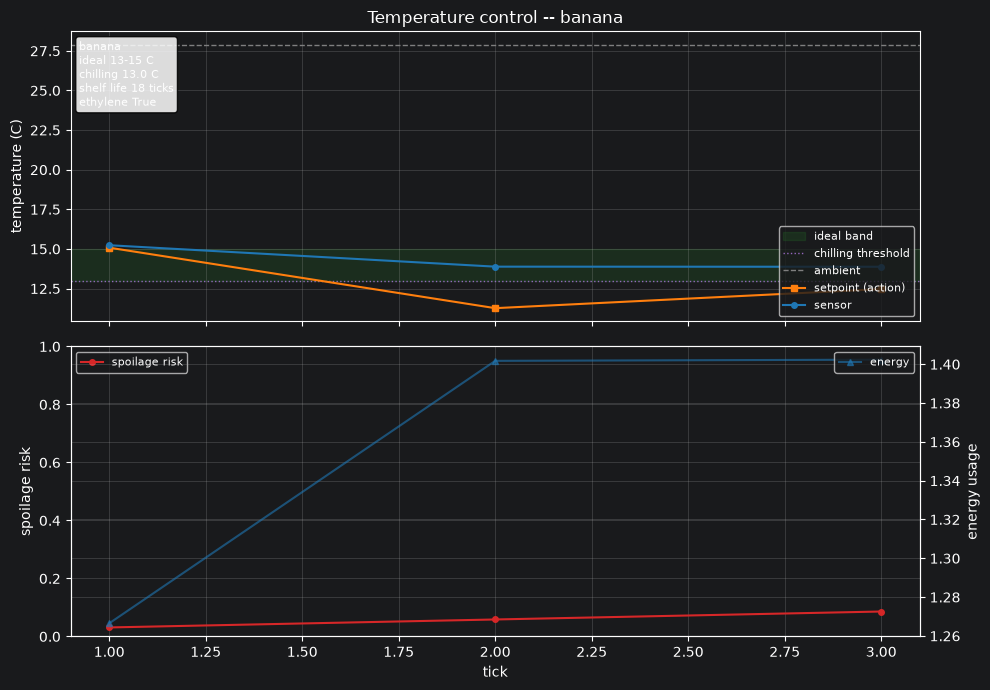

In [3]:
fig, (ax_t, ax_s) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax_t.axhspan(fruit.optimal_temp_low_c, fruit.optimal_temp_high_c, color="tab:green", alpha=0.15, label="ideal band")
if fruit.chilling_injury_threshold_c is not None:
    ax_t.axhline(fruit.chilling_injury_threshold_c, color="tab:purple", ls=":", lw=1, label="chilling threshold")
ax_t.axhline(meta["ambient_temp_c"], color="tab:gray", ls="--", lw=1, label="ambient")
ax_t.plot(df["tick"], df["desired"], marker="s", ms=4, color="tab:orange", label="setpoint (action)")
ax_t.plot(df["tick"], df["sensor"], marker="o", ms=4, color="tab:blue", label="sensor")
ax_t.set(ylabel="temperature (C)", title=f"Temperature control -- {meta['fruit']}")
ax_t.legend(loc="lower right", fontsize=8)

info = (f"{meta['fruit']}\n"
        f"ideal {fruit.optimal_temp_low_c:.0f}-{fruit.optimal_temp_high_c:.0f} C\n"
        f"chilling {fruit.chilling_injury_threshold_c} C\n"
        f"shelf life {fruit.base_shelf_life_ticks} ticks\n"
        f"ethylene {fruit.ethylene_sensitive}")
ax_t.text(0.01, 0.97, info, transform=ax_t.transAxes, va="top", ha="left", fontsize=8,
          bbox=dict(boxstyle="round", fc="white", alpha=0.85))

ax_s.plot(df["tick"], df["spoilage_risk"], marker="o", ms=4, color="tab:red", label="spoilage risk")
ax_s.set(xlabel="tick", ylabel="spoilage risk", ylim=(0, 1))
ax_e = ax_s.twinx()
ax_e.plot(df["tick"], df["energy"], marker="^", ms=4, color="tab:blue", alpha=0.6, label="energy")
ax_e.set_ylabel("energy usage")
ax_s.legend(loc="upper left", fontsize=8)
ax_e.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

## Route

Supply-chain graph, layered farm -> hub -> dc -> retail. Edge labels are distance (km).
Red = actual route taken; green dashed = target route (shortest by transit time).
Black ring = source, gold ring = target.

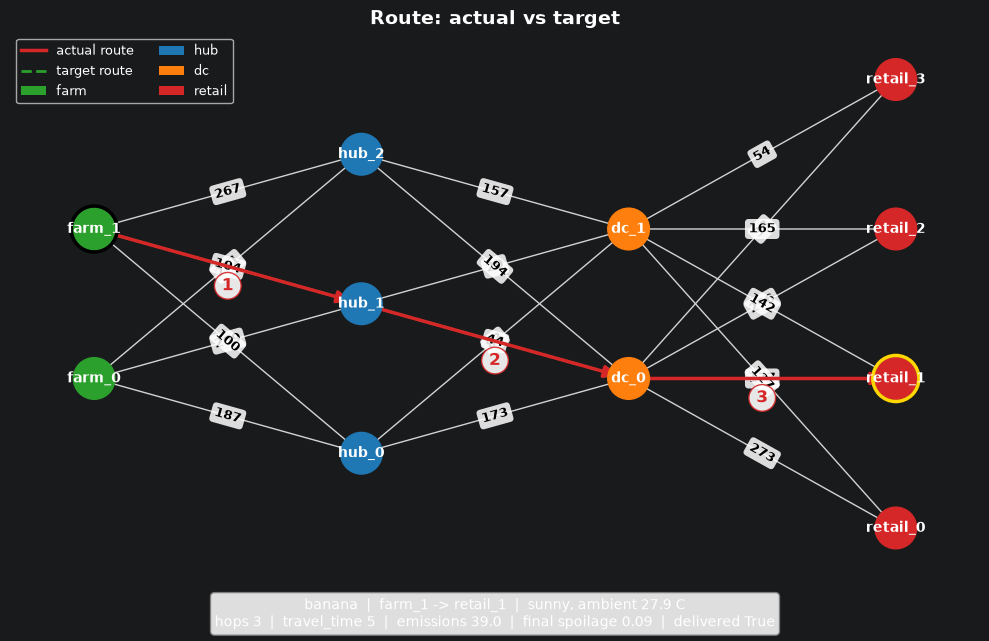

In [4]:
def layered_pos(graph):
    pos = {}
    for x, kind in enumerate(KIND_ORDER):
        nodes = [n for n, d in graph.nodes(data=True) if d["kind"] == kind]
        for i, n in enumerate(nodes):
            pos[n] = (float(x), i - (len(nodes) - 1) / 2)
    return pos


pos = layered_pos(graph)
fig, ax = plt.subplots(figsize=(10, 6.5))

transport = [(u, v) for u, v, d in graph.edges(data=True) if not d["wait"]]
nx.draw_networkx_edges(graph, pos, edgelist=transport, edge_color="lightgray", width=1, ax=ax)
edge_len = {(u, v): f"{d['distance_km']:.0f}" for u, v, d in graph.edges(data=True) if not d["wait"]}
nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_len, font_size=9, font_weight="bold", ax=ax,
                             bbox=dict(boxstyle="round", fc="white", ec="none", alpha=0.85))

node_colors = [KIND_COLOR[graph.nodes[n]["kind"]] for n in graph.nodes]
nx.draw_networkx_nodes(graph, pos, node_color=node_colors, node_size=900, ax=ax)
nx.draw_networkx_labels(graph, pos, font_size=10, font_weight="bold", font_color="white", ax=ax)

optimal = nx.shortest_path(graph, meta["source"], meta["target"], weight="base_transit_time")
opt_edges = list(zip(optimal, optimal[1:]))
nx.draw_networkx_edges(graph, pos, edgelist=opt_edges, edge_color="tab:green", style="dashed",
                       width=2, arrowsize=14, ax=ax)

hops = [(a, b) for a, b in zip(path, path[1:]) if a != b]
nx.draw_networkx_edges(graph, pos, edgelist=hops, edge_color="tab:red", width=2.5, arrowsize=18, ax=ax)
for order, (a, b) in enumerate(hops, start=1):
    x, y = (pos[a][0] + pos[b][0]) / 2, (pos[a][1] + pos[b][1]) / 2
    ax.text(x, y - 0.13, str(order), color="tab:red", fontsize=12, fontweight="bold",
            ha="center", va="center",
            bbox=dict(boxstyle="circle", fc="white", ec="tab:red", alpha=0.9))

for node, ring in [(meta["source"], "black"), (meta["target"], "gold")]:
    nx.draw_networkx_nodes(graph, pos, nodelist=[node], node_color="none", edgecolors=ring,
                           linewidths=2.5, node_size=1100, ax=ax)

travel, emis = df["route_travel_time"].iloc[-1], df["route_emissions"].iloc[-1]
caption = (f"{meta['fruit']}  |  {meta['source']} -> {meta['target']}  |  {meta['weather']}, "
           f"ambient {meta['ambient_temp_c']:.1f} C\n"
           f"hops {len(hops)}  |  travel_time {travel:.0f}  |  emissions {emis:.1f}  |  "
           f"final spoilage {df['spoilage_risk'].iloc[-1]:.2f}  |  delivered {delivered}")
ax.text(0.5, -0.04, caption, transform=ax.transAxes, ha="center", va="top", fontsize=10,
        bbox=dict(boxstyle="round", fc="#f5f5f5", ec="gray", alpha=0.9))

legend = [
    Line2D([0], [0], color="tab:red", lw=2.5, label="actual route"),
    Line2D([0], [0], color="tab:green", lw=2, ls="dashed", label="target route"),
]
legend += [Patch(fc=KIND_COLOR[k], label=k) for k in KIND_ORDER]
ax.legend(handles=legend, loc="upper left", fontsize=9, ncol=2)

ax.set_title("Route: actual vs target", fontsize=14, fontweight="bold")
ax.axis("off")
fig.tight_layout()
plt.show()

## Rewards

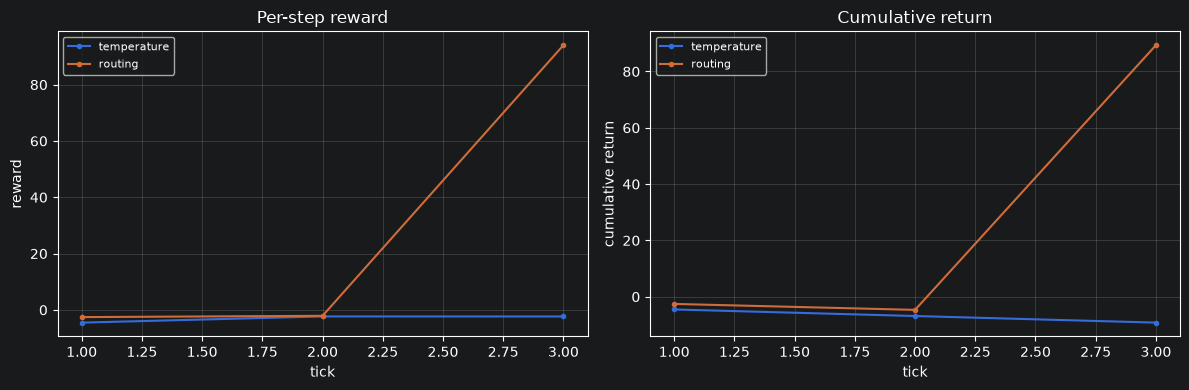

In [5]:
fig, (ax_r, ax_c) = plt.subplots(1, 2, figsize=(12, 4))
for a in AGENTS:
    col = f"reward_{a}"
    ax_r.plot(df["tick"], df[col], marker="o", ms=3, label=a)
    ax_c.plot(df["tick"], df[col].cumsum(), marker="o", ms=3, label=a)
ax_r.set(xlabel="tick", ylabel="reward", title="Per-step reward")
ax_c.set(xlabel="tick", ylabel="cumulative return", title="Cumulative return")
ax_r.legend(fontsize=8)
ax_c.legend(fontsize=8)
fig.tight_layout()
plt.show()